<a href="https://colab.research.google.com/github/ShekharJU/Machine_Learning_Lab_Sem4.1/blob/main/302311001008_SHEKHAR_BHARDWAJ_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SHEKHAR BHARDWAJ
#A3
#302311001008
#ML LAB ASSIGNMENT 2

#INSTALL & IMPORTS
This setup imports all the necessary libraries, metrics, models, and utilities to perform classification tasks, evaluate them thoroughly, and visualize results using datasets like wine or digits.

In [ ]:
pip install ucimlrepo

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine, load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report,accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.multiclass import OneVsRestClassifier

import warnings
warnings.filterwarnings("ignore")


#DIGITS
This code fetches the Optical Recognition of Handwritten Digits dataset from the UCI repository using ucimlrepo. It extracts the features (X) and target labels (y) as pandas DataFrames, prints dataset metadata and variable details, and then converts them into NumPy arrays for processing. The feature data is standardized using StandardScaler to improve model performance. Finally, the dataset is split into training and testing sets (70% training, 30% testing) while preserving class distribution with stratify.

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
optical_recognition_of_handwritten_digits = fetch_ucirepo(id=80)

# data (as pandas dataframes)
X = optical_recognition_of_handwritten_digits.data.features
y = optical_recognition_of_handwritten_digits.data.targets

# metadata
print(optical_recognition_of_handwritten_digits.metadata)

# variable information
print(optical_recognition_of_handwritten_digits.variables)



{'uci_id': 80, 'name': 'Optical Recognition of Handwritten Digits', 'repository_url': 'https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits', 'data_url': 'https://archive.ics.uci.edu/static/public/80/data.csv', 'abstract': 'Two versions of this database available; see folder', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 5620, 'num_features': 64, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Wed Aug 23 2023', 'dataset_doi': '10.24432/C50P49', 'creators': ['E. Alpaydin', 'C. Kaynak'], 'intro_paper': {'ID': 280, 'type': 'NATIVE', 'title': 'Methods of Combining Multiple Classifiers and Their Applications to Handwritten Digit Recognition', 'authors': 'C. Kaynak', 'venue': 'MSc Thesis, Institute of Graduate Studies in Science and Engineering, 

In [ ]:
print(X)


      Attribute1  Attribute2  Attribute3  Attribute4  Attribute5  Attribute6  \
0              0           1           6          15          12           1   
1              0           0          10          16           6           0   
2              0           0           8          15          16          13   
3              0           0           0           3          11          16   
4              0           0           5          14           4           0   
...          ...         ...         ...         ...         ...         ...   
5615           0           0           4          10          13           6   
5616           0           0           6          16          13          11   
5617           0           0           1          11          15           1   
5618           0           0           2          10           7           0   
5619           0           0          10          14           8           1   

      Attribute7  Attribute8  Attribute

In [ ]:
print(y)

      class
0         0
1         0
2         7
3         4
4         6
...     ...
5615      9
5616      0
5617      8
5618      9
5619      8

[5620 rows x 1 columns]


In [ ]:
X_digits = X.values
y_digits = y.values.ravel()
print(X_digits)
print(y)
scaler = StandardScaler()
X_digits = scaler.fit_transform(X_digits)

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_digits, y_digits, train_size=0.7, stratify=y_digits, random_state=42
)

[[ 0  1  6 ...  1  0  0]
 [ 0  0 10 ...  3  0  0]
 [ 0  0  8 ...  0  0  0]
 ...
 [ 0  0  1 ...  6  0  0]
 [ 0  0  2 ... 12  0  0]
 [ 0  0 10 ... 12  1  0]]
      class
0         0
1         0
2         7
3         4
4         6
...     ...
5615      9
5616      0
5617      8
5618      9
5619      8

[5620 rows x 1 columns]


#SVM
This code defines a function evaluate_svm that trains an SVM model, makes predictions, and evaluates performance on a given dataset. It prints accuracy, precision, recall, F1-score, and a detailed classification report, then visualizes the confusion matrix with a heatmap. If the task is multi-class, it also plots ROC curves for each class. The function is then used to train and evaluate SVM classifiers with four different kernels—linear, polynomial, RBF, and sigmoid—on the digits dataset, allowing performance comparison across kernels.

In [ ]:
def evaluate_svm(model, X_train, X_test, y_train, y_test, dataset_name, kernel):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n[{dataset_name}] SVM-{kernel}")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{dataset_name} - SVM-{kernel} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ROC Curve (only if multi-class possible)
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
    if y_test_bin.shape[1] > 1:
        y_score = model.decision_function(X_test)
        fpr, tpr, roc_auc = {}, {}, {}
        plt.figure()
        for i in range(y_test_bin.shape[1]):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC={roc_auc[i]:.2f})')
        plt.plot([0,1],[0,1],'--',color='gray')
        plt.title(f"ROC Curve: {dataset_name} - SVM-{kernel}")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()


[Digits] SVM-Linear
Accuracy: 0.9787, Precision: 0.9789, Recall: 0.9787, F1: 0.9787

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       166
           1       0.95      0.98      0.97       171
           2       1.00      0.99      1.00       167
           3       0.94      0.99      0.97       172
           4       0.99      0.99      0.99       171
           5       0.98      0.98      0.98       167
           6       1.00      0.99      0.99       168
           7       0.99      0.98      0.99       170
           8       0.96      0.95      0.95       166
           9       0.96      0.95      0.96       169

    accuracy                           0.98      1687
   macro avg       0.98      0.98      0.98      1687
weighted avg       0.98      0.98      0.98      1687



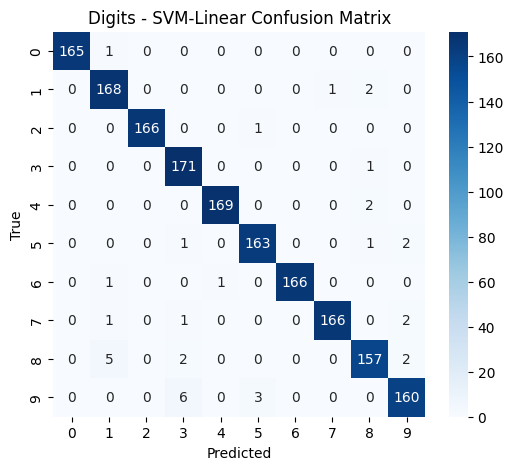

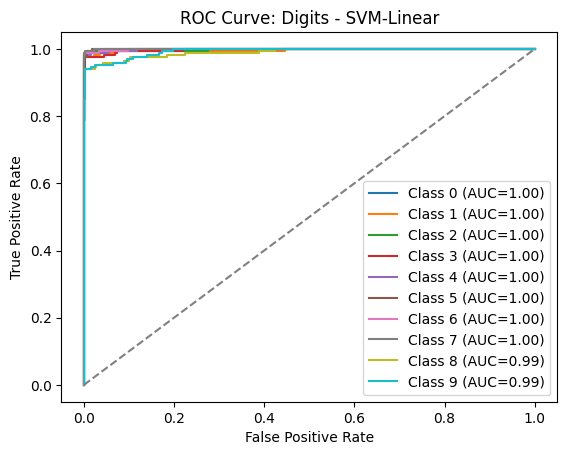

In [ ]:
# Digits - SVM Linear
svm_linear_digits = SVC(kernel="linear", probability=True, random_state=42)
evaluate_svm(svm_linear_digits, Xd_train, Xd_test, yd_train, yd_test, "Digits", "Linear")



[Digits] SVM-Polynomial
Accuracy: 0.9757, Precision: 0.9786, Recall: 0.9757, F1: 0.9763

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       166
           1       1.00      0.99      0.99       171
           2       1.00      0.98      0.99       167
           3       0.99      0.96      0.98       172
           4       1.00      0.98      0.99       171
           5       0.98      0.97      0.98       167
           6       1.00      0.98      0.99       168
           7       0.99      0.99      0.99       170
           8       0.84      1.00      0.91       166
           9       0.98      0.94      0.96       169

    accuracy                           0.98      1687
   macro avg       0.98      0.98      0.98      1687
weighted avg       0.98      0.98      0.98      1687



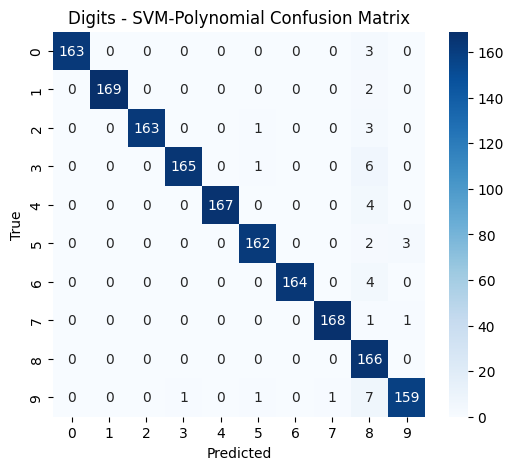

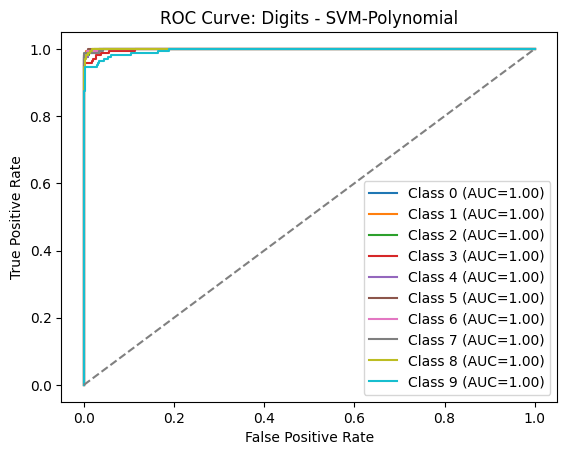

In [ ]:
# Digits - SVM Polynomial
svm_poly_digits = SVC(kernel="poly", probability=True, random_state=42)
evaluate_svm(svm_poly_digits, Xd_train, Xd_test, yd_train, yd_test, "Digits", "Polynomial")



[Digits] SVM-RBF
Accuracy: 0.9864, Precision: 0.9865, Recall: 0.9864, F1: 0.9864

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       166
           1       0.99      0.99      0.99       171
           2       0.99      0.99      0.99       167
           3       0.98      0.99      0.99       172
           4       0.97      0.99      0.98       171
           5       0.99      0.99      0.99       167
           6       0.99      0.99      0.99       168
           7       0.99      0.98      0.99       170
           8       0.99      0.96      0.98       166
           9       0.97      0.96      0.97       169

    accuracy                           0.99      1687
   macro avg       0.99      0.99      0.99      1687
weighted avg       0.99      0.99      0.99      1687



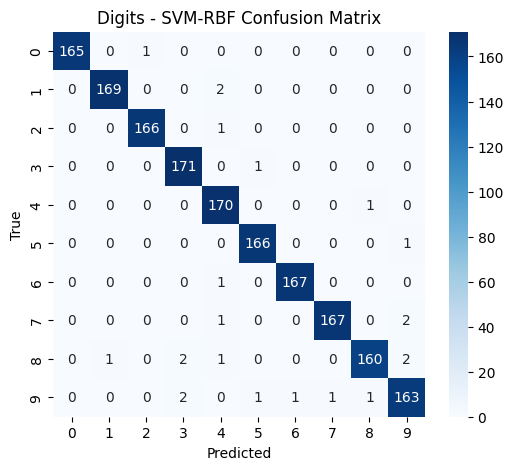

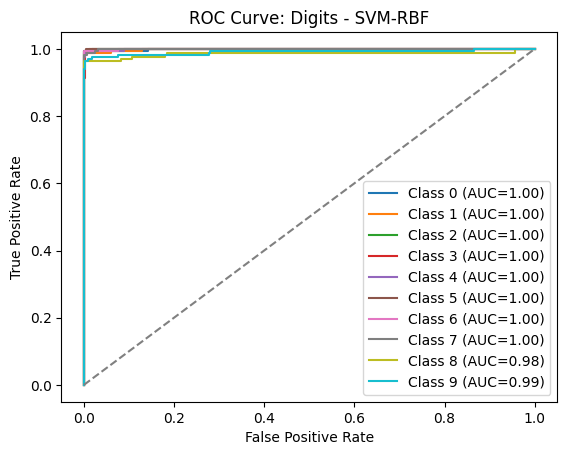

In [ ]:
# Digits - SVM RBF (Gaussian)
svm_rbf_digits = SVC(kernel="rbf", probability=True, random_state=42)
evaluate_svm(svm_rbf_digits, Xd_train, Xd_test, yd_train, yd_test, "Digits", "RBF")




[Digits] SVM-Sigmoid
Accuracy: 0.9425, Precision: 0.9431, Recall: 0.9425, F1: 0.9427

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       166
           1       0.87      0.89      0.88       171
           2       0.90      0.95      0.92       167
           3       0.96      0.97      0.96       172
           4       0.95      0.92      0.93       171
           5       0.95      0.95      0.95       167
           6       0.99      0.97      0.98       168
           7       0.92      0.95      0.94       170
           8       0.94      0.92      0.93       166
           9       0.95      0.92      0.94       169

    accuracy                           0.94      1687
   macro avg       0.94      0.94      0.94      1687
weighted avg       0.94      0.94      0.94      1687



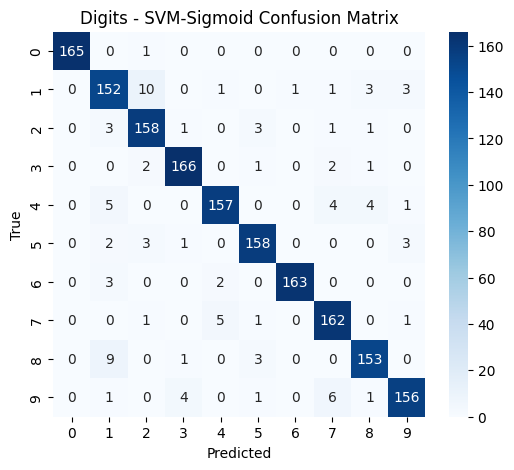

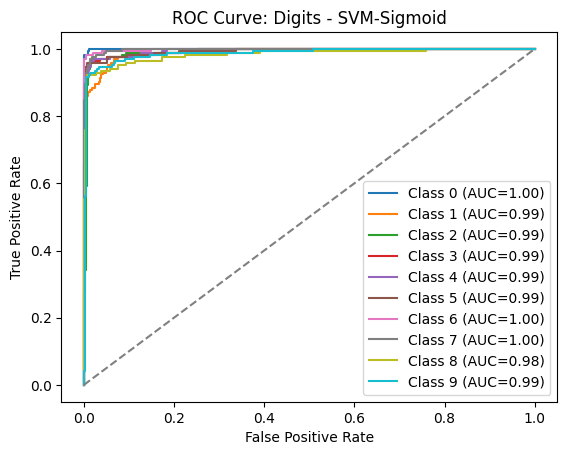

In [ ]:
# Digits - SVM Sigmoid
svm_sigmoid_digits = SVC(kernel="sigmoid", probability=True, random_state=42)
evaluate_svm(svm_sigmoid_digits, Xd_train, Xd_test, yd_train, yd_test, "Digits", "Sigmoid")


#MLP
This code defines a function evaluate_mlp to train and evaluate a Multi-Layer Perceptron (MLP) neural network classifier on a dataset. The function builds an MLPClassifier with customizable parameters such as hidden layer size, learning rate, momentum, and number of iterations. It trains the model, predicts on the test set, and computes performance metrics (accuracy, precision, recall, F1-score). It also prints a classification report, plots a confusion matrix heatmap, and, for multi-class tasks, plots ROC curves using predicted probabilities. Finally, the function is called with one hidden layer of 100 neurons, a learning rate of 0.01, momentum of 0.9, and 200 training iterations on the Optical Digits dataset.

In [ ]:


def evaluate_mlp(hidden_layer_sizes, learning_rate_init, momentum, max_iter,
                 X_train, X_test, y_train, y_test, dataset_name):
    # Define MLP
    model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes,
                          learning_rate_init=learning_rate_init,
                          momentum=momentum,
                          max_iter=max_iter,
                          random_state=42)

    # Train
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n[{dataset_name}] MLP")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{dataset_name} - MLP Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ROC Curve
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
    if y_test_bin.shape[1] > 1:
        y_score = model.predict_proba(X_test)   # ✅ use predict_proba for MLP
        fpr, tpr, roc_auc = {}, {}, {}
        plt.figure()
        for i in range(y_test_bin.shape[1]):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC={roc_auc[i]:.2f})')
        plt.plot([0,1],[0,1],'--',color='gray')
        plt.title(f"ROC Curve: {dataset_name} - MLP")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()



[Optical Digits] MLP
Accuracy: 0.9858, Precision: 0.9858, Recall: 0.9858, F1: 0.9858

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       166
           1       0.99      0.99      0.99       171
           2       0.99      0.99      0.99       167
           3       0.99      0.99      0.99       172
           4       0.99      0.99      0.99       171
           5       0.98      0.98      0.98       167
           6       0.99      0.99      0.99       168
           7       0.99      0.99      0.99       170
           8       0.97      0.98      0.97       166
           9       0.97      0.96      0.97       169

    accuracy                           0.99      1687
   macro avg       0.99      0.99      0.99      1687
weighted avg       0.99      0.99      0.99      1687



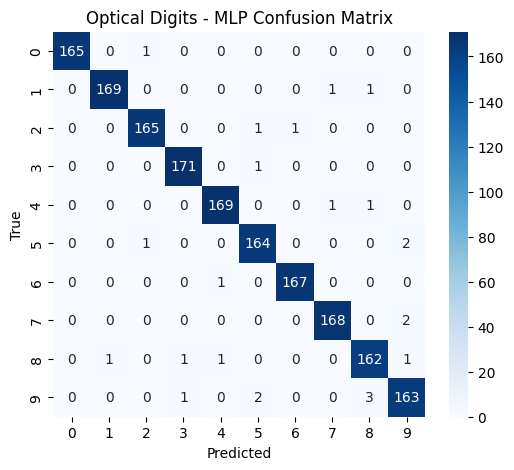

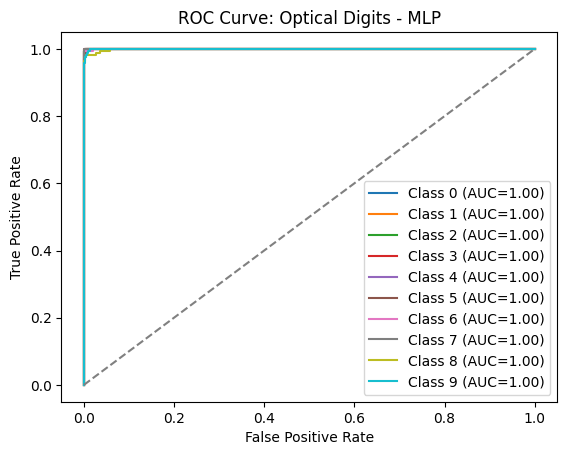

In [ ]:
evaluate_mlp(hidden_layer_sizes=(100,),   # one hidden layer with 100 neurons
             learning_rate_init=0.01,     # learning rate
             momentum=0.9,                # momentum term
             max_iter=200,                # epoch size
             X_train=Xd_train, X_test=Xd_test,
             y_train=yd_train, y_test=yd_test,
             dataset_name="Optical Digits")


#Random Forest
This code defines a function evaluate_random_forest to train and evaluate a Random Forest classifier on a dataset. The function fits the given model, predicts labels on the test set, and calculates key performance metrics—accuracy, precision, recall, and F1-score. It prints a detailed classification report, displays a confusion matrix heatmap to visualize misclassifications, and plots ROC curves for each class in multi-class classification using predicted probabilities. Finally, it initializes a RandomForestClassifier with 100 trees and evaluates it on the Optical Digits dataset using the defined function.

In [ ]:
def evaluate_random_forest(model, X_train, X_test, y_train, y_test, dataset_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n[{dataset_name}] Random Forest")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{dataset_name} - Random Forest Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ROC Curve (multi-class case handled)
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
    if y_test_bin.shape[1] > 1:
        y_score = model.predict_proba(X_test)   # For RF, use predict_proba
        fpr, tpr, roc_auc = {}, {}, {}
        plt.figure()
        for i in range(y_test_bin.shape[1]):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC={roc_auc[i]:.2f})')
        plt.plot([0,1],[0,1],'--',color='gray')
        plt.title(f"ROC Curve: {dataset_name} - Random Forest")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()


[Optical Digits] Random Forest
Accuracy: 0.9846, Precision: 0.9847, Recall: 0.9846, F1: 0.9846

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       166
           1       0.99      1.00      0.99       171
           2       1.00      0.99      1.00       167
           3       0.99      0.97      0.98       172
           4       0.98      0.97      0.98       171
           5       0.99      0.98      0.98       167
           6       0.99      0.99      0.99       168
           7       0.98      0.99      0.99       170
           8       0.96      0.99      0.98       166
           9       0.97      0.96      0.97       169

    accuracy                           0.98      1687
   macro avg       0.98      0.98      0.98      1687
weighted avg       0.98      0.98      0.98      1687



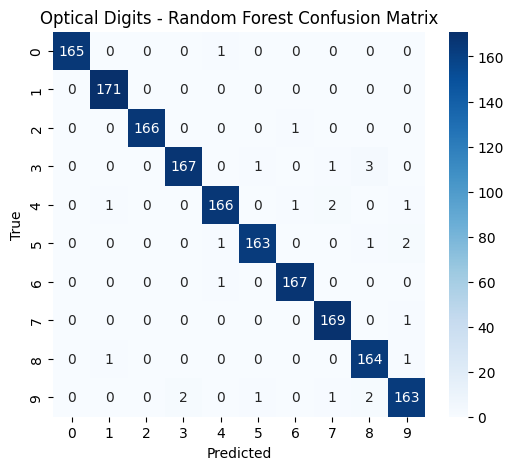

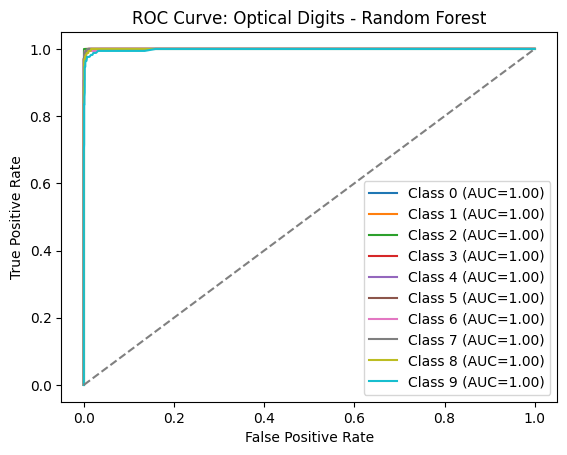

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_random_forest(rf_model, Xd_train, Xd_test, yd_train, yd_test, dataset_name="Optical Digits")

#Split Data
This code evaluates how the accuracy of three classifiers—SVM (with RBF kernel), MLP neural network, and Random Forest—changes with different train-test split ratios. It loops through test sizes from 0.1 to 0.9, repeatedly splitting the Optical Digits dataset into training and test sets. For each split, it trains all three models, records their test accuracy, and stores the results. Finally, it plots a line graph showing accuracy versus test size for all three models, allowing easy comparison of how model performance varies as the test set proportion increases.

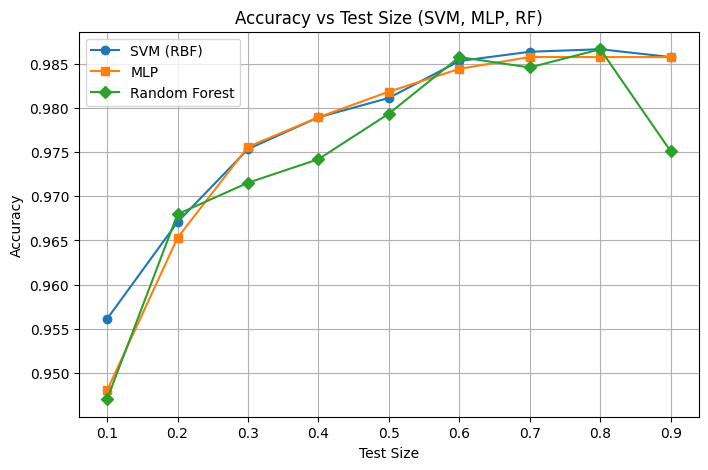

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

splits = range(1, 10)   # test sizes from 0.1 to 0.9
accs_svm = []
accs_mlp = []
accs_rf = []



for s in splits:
    test_size = s / 10


    X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, train_size=test_size, stratify=y_digits, random_state=42)


    # --- SVM ---
    svm_model = SVC(kernel="rbf", probability=True, random_state=42)
    svm_model.fit(X_train, y_train)
    accs_svm.append(accuracy_score(y_test, svm_model.predict(X_test)))

    # --- MLP ---
    mlp_model = MLPClassifier(
        hidden_layer_sizes=(100,),
        learning_rate_init=0.01,
        momentum=0.9,
        max_iter=200,
        random_state=42
    )
    mlp_model.fit(X_train, y_train)
    accs_mlp.append(accuracy_score(y_test, mlp_model.predict(X_test)))

    # --- Random Forest ---
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    accs_rf.append(accuracy_score(y_test, rf_model.predict(X_test)))

# Convert to fractions
splits = [s/10 for s in splits]

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(splits, accs_svm, marker="o", label="SVM (RBF)")
plt.plot(splits, accs_mlp, marker="s", label="MLP")
plt.plot(splits, accs_rf, marker="D", label="Random Forest")
plt.xlabel("Test Size")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Test Size (SVM, MLP, RF)")
plt.legend()
plt.grid(True)
plt.show()


#PCA
This code applies Principal Component Analysis (PCA) to reduce the high-dimensional Optical Digits dataset down to 40 principal components for training and testing, and separately visualizes the training set in 2D using the first two components. It plots a scatter plot where each digit class (0–9) is shown in a different color, illustrating how the digits are distributed in reduced feature space. After dimensionality reduction, the code trains and evaluates two classifiers—Random Forest and MLP neural network—on the PCA-transformed data using the previously defined evaluation functions, printing performance metrics, confusion matrices, and ROC curves. This shows how well these models perform when trained on reduced-dimensional features instead of the full dataset.

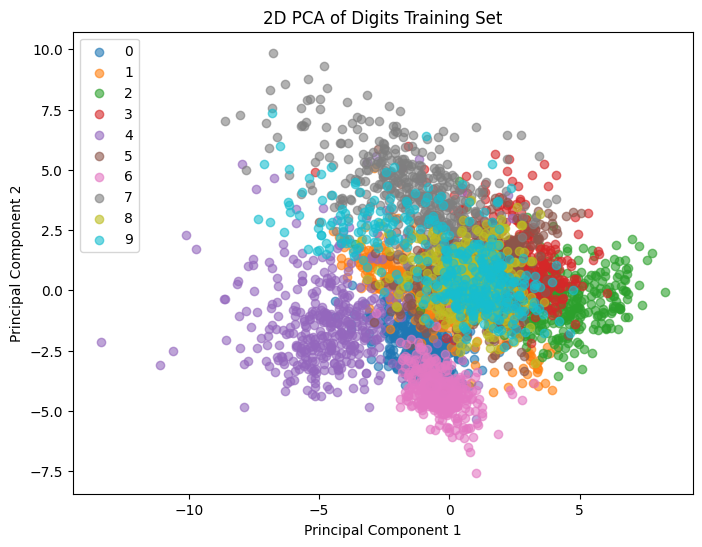

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA to reduce to 2 dimensions for visualization
pca_2d = PCA(n_components=40)
X_digits_2d = pca_2d.fit_transform(X_digits)
Xd_train_2d, Xd_test_2d, yd_train_2d, yd_test_2d = train_test_split(
    X_digits_2d, y_digits, train_size=0.7, stratify=y_digits, random_state=42
)
# Plot the 2D PCA projection
plt.figure(figsize=(8,6))
for digit in range(10):
    plt.scatter(
        Xd_train_2d[yd_train_2d == digit, 0],
        Xd_train_2d[yd_train_2d == digit, 1],
        label=str(digit), alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA of Digits Training Set")
plt.legend()
plt.show()


In [ ]:
Xd_train_2d[0].size

40


[Optical Digits] Random Forest
Accuracy: 0.9692, Precision: 0.9696, Recall: 0.9692, F1: 0.9692

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       166
           1       0.99      0.99      0.99       171
           2       1.00      0.98      0.99       167
           3       0.95      0.98      0.96       172
           4       0.96      0.96      0.96       171
           5       0.99      0.93      0.96       167
           6       1.00      0.99      1.00       168
           7       0.96      0.96      0.96       170
           8       0.93      0.96      0.94       166
           9       0.92      0.93      0.93       169

    accuracy                           0.97      1687
   macro avg       0.97      0.97      0.97      1687
weighted avg       0.97      0.97      0.97      1687



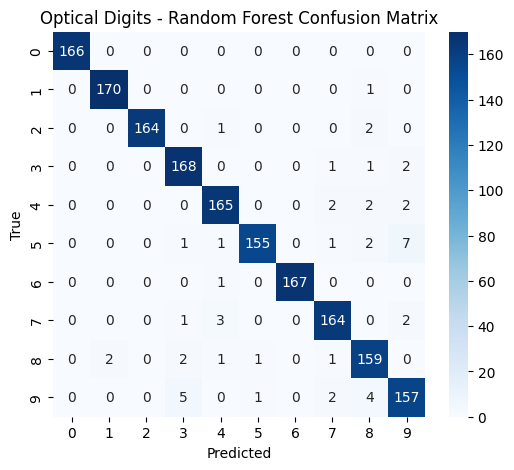

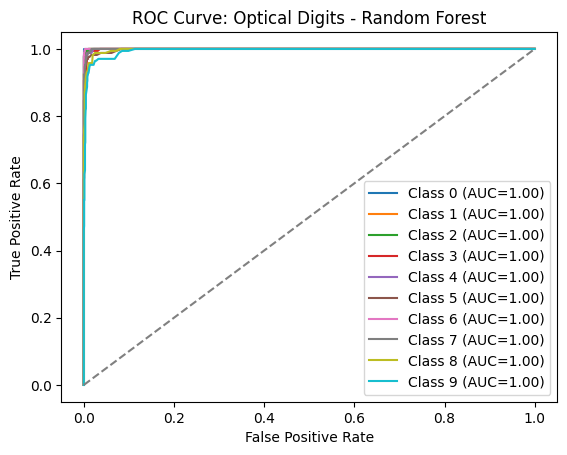

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_random_forest(rf_model, Xd_train_2d, Xd_test_2d, yd_train_2d, yd_test_2d, dataset_name="Optical Digits")


[Digits] SVM-Linear
Accuracy: 0.9804, Precision: 0.9805, Recall: 0.9804, F1: 0.9804

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       166
           1       0.96      0.99      0.98       171
           2       0.99      0.99      0.99       167
           3       0.97      0.99      0.98       172
           4       0.99      0.98      0.99       171
           5       0.99      0.99      0.99       167
           6       0.99      0.98      0.99       168
           7       0.99      0.98      0.99       170
           8       0.96      0.96      0.96       166
           9       0.96      0.95      0.95       169

    accuracy                           0.98      1687
   macro avg       0.98      0.98      0.98      1687
weighted avg       0.98      0.98      0.98      1687



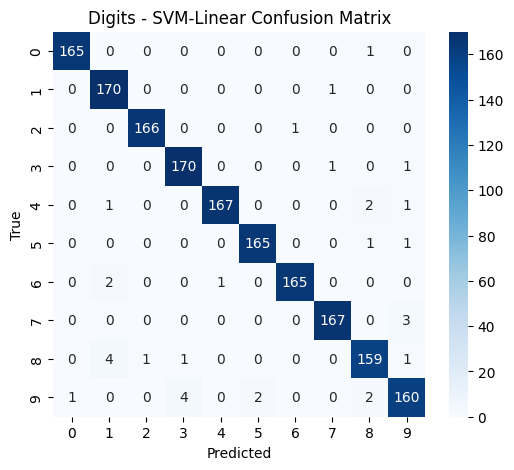

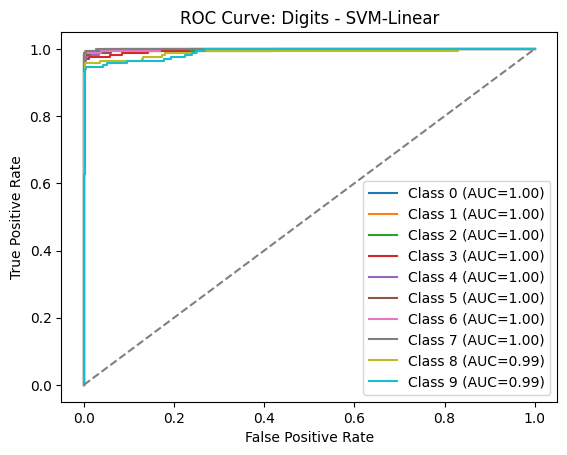

In [ ]:
# Digits - SVM Linear
svm_linear_digits = SVC(kernel="linear", probability=True, random_state=42)
evaluate_svm(svm_linear_digits, Xd_train_2d, Xd_test_2d, yd_train_2d, yd_test_2d, "Digits", "Linear")



[Optical Digits] MLP
Accuracy: 0.9846, Precision: 0.9846, Recall: 0.9846, F1: 0.9846

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       166
           1       0.99      0.99      0.99       171
           2       0.98      0.99      0.99       167
           3       0.99      0.99      0.99       172
           4       0.98      0.98      0.98       171
           5       0.98      0.97      0.98       167
           6       1.00      0.99      1.00       168
           7       0.98      0.99      0.99       170
           8       0.96      0.98      0.97       166
           9       0.98      0.96      0.97       169

    accuracy                           0.98      1687
   macro avg       0.98      0.98      0.98      1687
weighted avg       0.98      0.98      0.98      1687



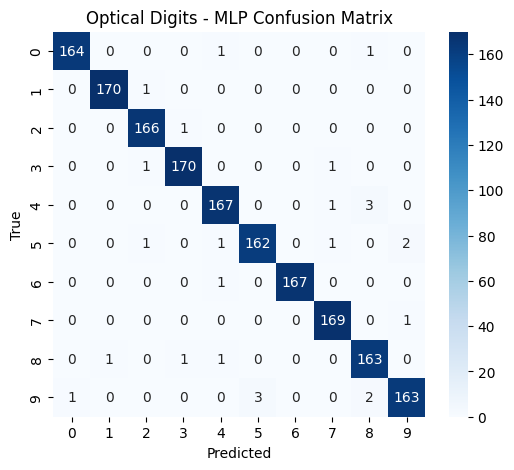

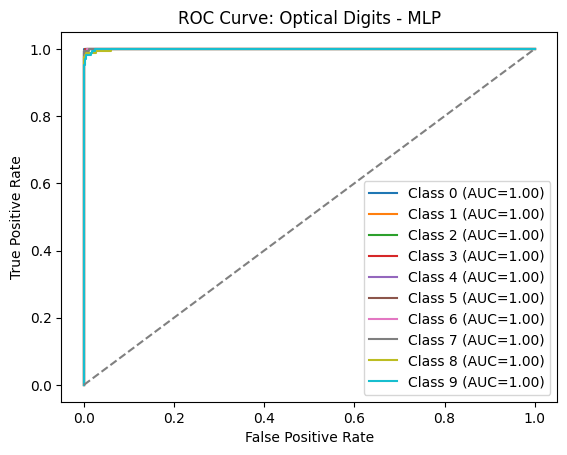

In [ ]:
evaluate_mlp(hidden_layer_sizes=(100,),   # one hidden layer with 100 neurons
             learning_rate_init=0.01,     # learning rate
             momentum=0.9,                # momentum term
             max_iter=200,                # epoch size
             X_train=Xd_train_2d, X_test=Xd_test_2d,
             y_train=yd_train_2d, y_test=yd_test_2d,
             dataset_name="Optical Digits")


#

#Wine
This code loads the Wine dataset directly from the UCI repository, assigns meaningful column names, and displays the first few rows for inspection. It separates the dataset into features (X_wine) and target labels (y_wine), then splits it into training (70%) and testing (30%) sets while preserving class distribution using stratify. After splitting, it standardizes the features with StandardScaler to normalize values (zero mean, unit variance), which is important for models sensitive to feature scale. Finally, it prints the shapes of the train/test splits before and after scaling to confirm successful preprocessing.

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data"
wine_data = pd.read_csv(url, header=None)

# Assign column names
wine_data.columns = [
    "class", "alcohol", "malic_acid", "ash", "alcalinity_of_ash",
    "magnesium", "total_phenols", "flavanoids", "nonflavanoid_phenols",
    "proanthocyanins", "color_intensity", "hue", "od280/od315_of_diluted_wines",
    "proline"
]

display(wine_data.head())

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
from sklearn.model_selection import train_test_split

X_wine = wine_data.drop("class", axis=1)
y_wine = wine_data["class"]

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_wine, y_wine, test_size=0.3, random_state=42, stratify=y_wine
)

print("Wine dataset split:")
print(f"Xw_train shape: {Xw_train.shape}")
print(f"Xw_test shape: {Xw_test.shape}")
print(f"yw_train shape: {yw_train.shape}")
print(f"yw_test shape: {yw_test.shape}")

Wine dataset split:
Xw_train shape: (124, 13)
Xw_test shape: (54, 13)
yw_train shape: (124,)
yw_test shape: (54,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_wine = StandardScaler()
Xw_train = scaler_wine.fit_transform(Xw_train)
Xw_test = scaler_wine.transform(Xw_test)

print("\nWine dataset scaled:")
print(f"Xw_train scaled shape: {Xw_train.shape}")
print(f"Xw_test scaled shape: {Xw_test.shape}")


Wine dataset scaled:
Xw_train scaled shape: (124, 13)
Xw_test scaled shape: (54, 13)


In [ ]:
Xw_train

array([[ 0.98268636, -0.52764049,  0.17359827, ...,  0.85746167,
         0.43782507,  1.86317967],
       [ 0.95793708, -0.74551086,  1.25550363, ...,  1.03209459,
         0.15956344,  1.74910798],
       [ 0.40107814, -0.61289411,  1.77780276, ...,  0.59551231,
         0.26208088,  0.42913559],
       ...,
       [ 0.19070921, -0.36660586,  1.44203903, ..., -1.50008262,
        -1.86149473, -1.05379636],
       [-0.87351008,  2.30467436,  0.65859033, ..., -0.88886743,
        -1.94936683, -0.09233499],
       [-0.390899  , -0.87812761, -1.28137789, ...,  0.1152718 ,
        -1.48071566, -0.97231658]])

In [ ]:
yw_train

,class
12,1
30,1
36,1
31,1
120,2
...,...
168,3
114,2
152,3
136,3


#SVM Wine
This code tests the Wine dataset with SVM classifiers using four kernels: Polynomial, Linear, RBF, and Sigmoid. Each model is trained and evaluated using accuracy, precision, recall, F1-score, confusion matrix, and ROC curves. The Linear kernel works well for linearly separable data, Polynomial and RBF capture non-linear patterns, while Sigmoid behaves like a neural network activation but is less commonly effective. This allows comparison of how different kernels perform on the same dataset.


[Wine] SVM-Linear
Accuracy: 0.9630, Precision: 0.9639, Recall: 0.9630, F1: 0.9629

Classification Report:
              precision    recall  f1-score   support

           1       0.95      1.00      0.97        18
           2       0.95      0.95      0.95        21
           3       1.00      0.93      0.97        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54



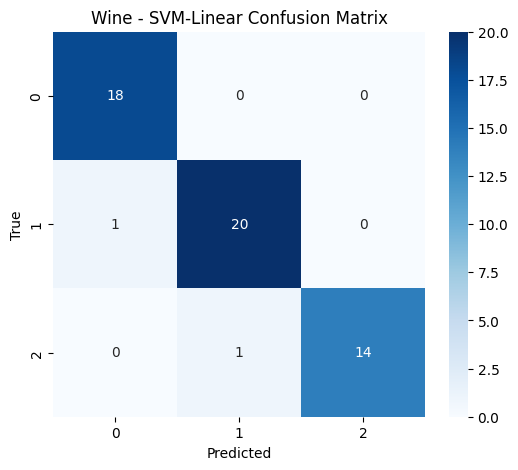

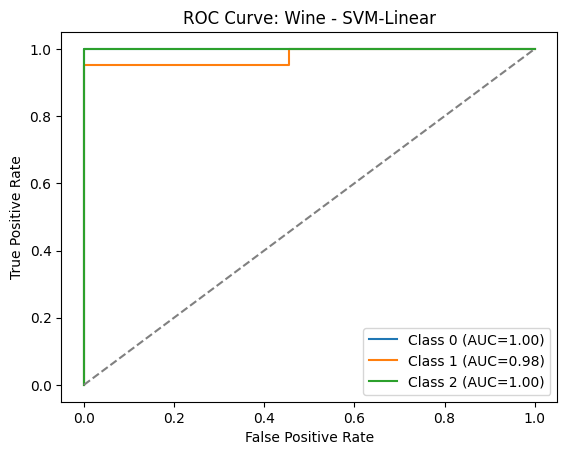

In [ ]:
# Digits - SVM Linear
svm_linear_wine = SVC(kernel="linear", probability=True, random_state=42)
evaluate_svm(svm_linear_wine, Xw_train, Xw_test, yw_train, yw_test, "Wine", "Linear")



[wine] SVM-Polynomial
Accuracy: 0.9074, Precision: 0.9252, Recall: 0.9074, F1: 0.9085

Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.83      0.91        18
           2       0.81      1.00      0.89        21
           3       1.00      0.87      0.93        15

    accuracy                           0.91        54
   macro avg       0.94      0.90      0.91        54
weighted avg       0.93      0.91      0.91        54



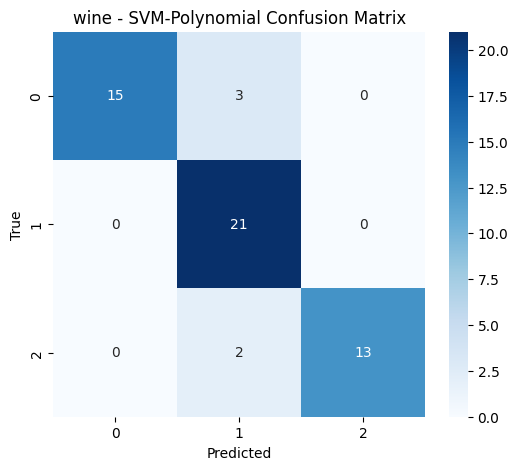

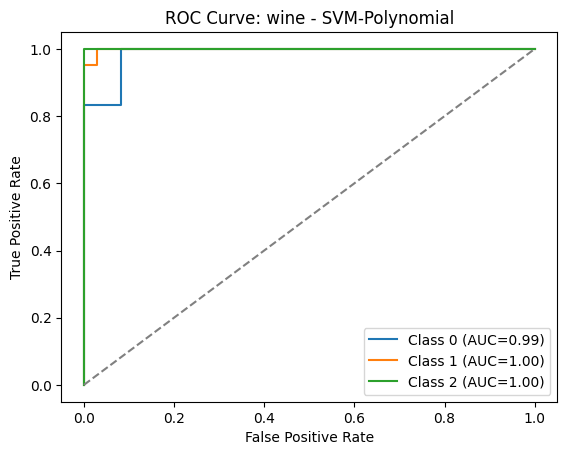

In [ ]:
# Digits - SVM Polynomial
svm_poly_wine = SVC(kernel="poly", probability=True, random_state=42)
evaluate_svm(svm_poly_wine, Xw_train, Xw_test, yw_train, yw_test, "wine", "Polynomial")



[wine] SVM-RBF
Accuracy: 0.9815, Precision: 0.9823, Recall: 0.9815, F1: 0.9814

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        18
           2       0.95      1.00      0.98        21
           3       1.00      0.93      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



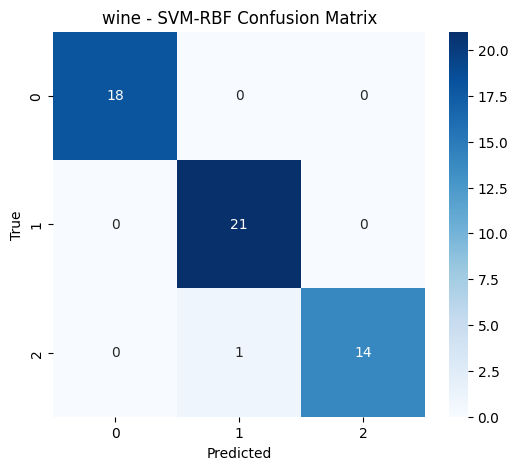

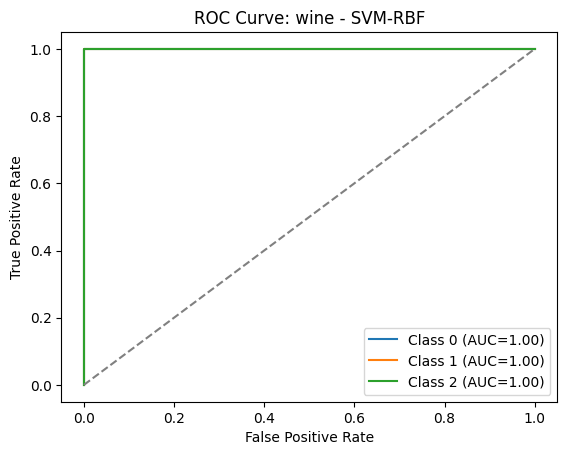

In [ ]:
# Digits - SVM RBF (Gaussian)
svm_rbf_wine = SVC(kernel="rbf", probability=True, random_state=42)
evaluate_svm(svm_rbf_wine, Xw_train, Xw_test, yw_train, yw_test, "wine", "RBF")




[wine] SVM-Sigmoid
Accuracy: 0.9630, Precision: 0.9651, Recall: 0.9630, F1: 0.9626

Classification Report:
              precision    recall  f1-score   support

           1       0.95      1.00      0.97        18
           2       1.00      0.90      0.95        21
           3       0.94      1.00      0.97        15

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54



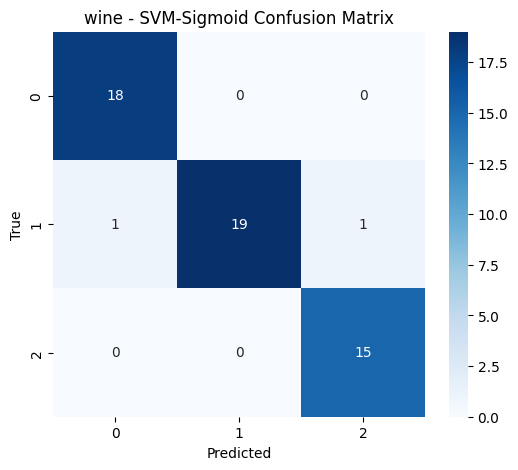

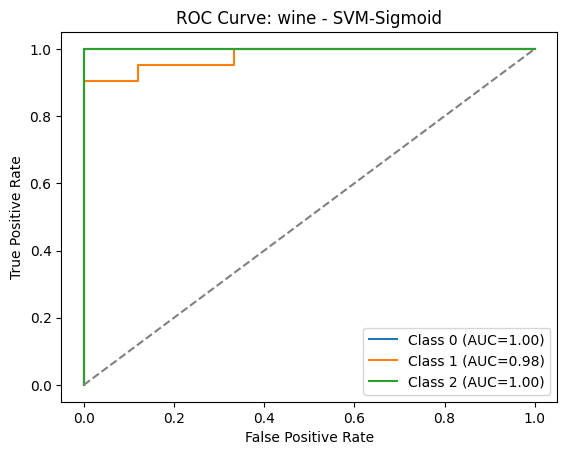

In [ ]:
# Digits - SVM Sigmoid
svm_sigmoid_wine = SVC(kernel="sigmoid", probability=True, random_state=42)
evaluate_svm(svm_sigmoid_wine, Xw_train, Xw_test, yw_train, yw_test, "wine", "Sigmoid")


#MLP WINE
This code evaluates the Wine dataset using a Multi-Layer Perceptron (MLP) neural network. The model is built with a single hidden layer of 100 neurons, a learning rate of 0.01, momentum of 0.9, and trained for up to 200 iterations. After training, the evaluate_mlp function measures performance by calculating accuracy, precision, recall, and F1-score, along with generating a classification report. It also visualizes results using a confusion matrix heatmap and ROC curves for the three wine classes. This provides a clear assessment of how well the MLP can classify different types of wine.


[Wine] MLP
Accuracy: 0.9630, Precision: 0.9630, Recall: 0.9630, F1: 0.9630

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        18
           2       0.95      0.95      0.95        21
           3       0.93      0.93      0.93        15

    accuracy                           0.96        54
   macro avg       0.96      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54



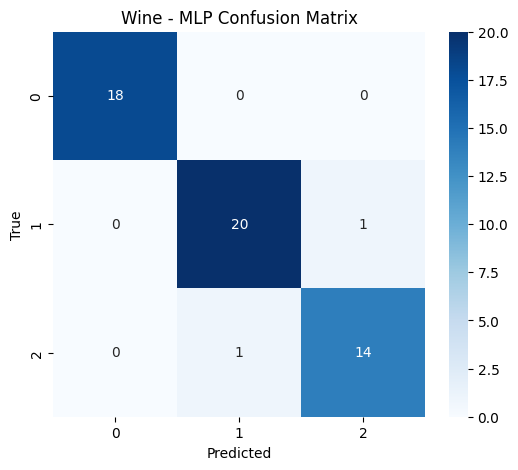

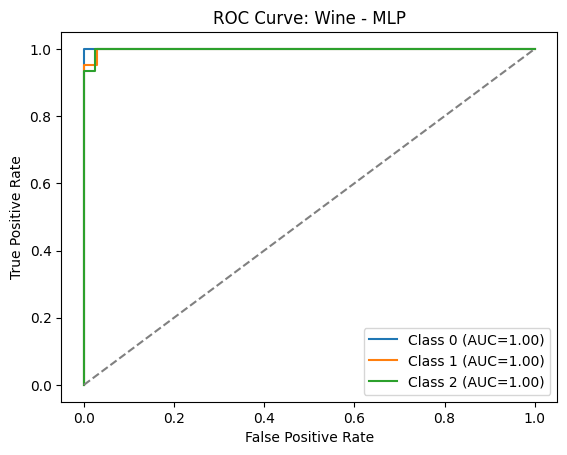

In [ ]:
evaluate_mlp(hidden_layer_sizes=(100,),   # one hidden layer with 100 neurons
             learning_rate_init=0.01,     # learning rate
             momentum=0.9,                # momentum term
             max_iter=200,                # epoch size
             X_train=Xw_train, X_test=Xw_test,
             y_train=yw_train, y_test=yw_test,
             dataset_name="Wine")


#RF WINE
This code applies a Random Forest classifier to the Wine dataset. The model is created with 95 decision trees (n_estimators=95) and a fixed random state for reproducibility. It is then trained on the scaled training data and tested on the test set using the evaluate_random_forest function. The evaluation reports performance metrics such as accuracy, precision, recall, and F1-score, along with a classification report. It also visualizes the results through a confusion matrix heatmap and ROC curves for the three wine classes, giving a complete picture of how well the Random Forest model classifies wines.


[Wine] Random Forest
Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        21
           3       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



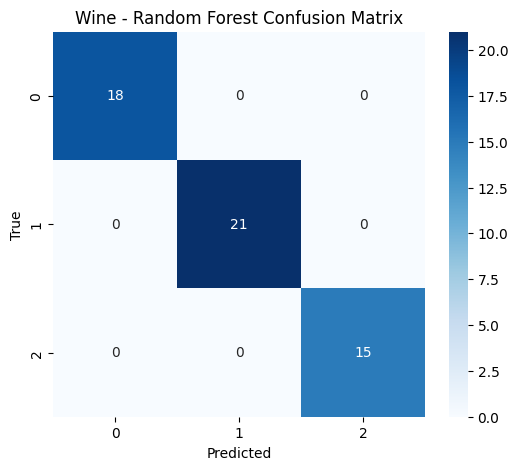

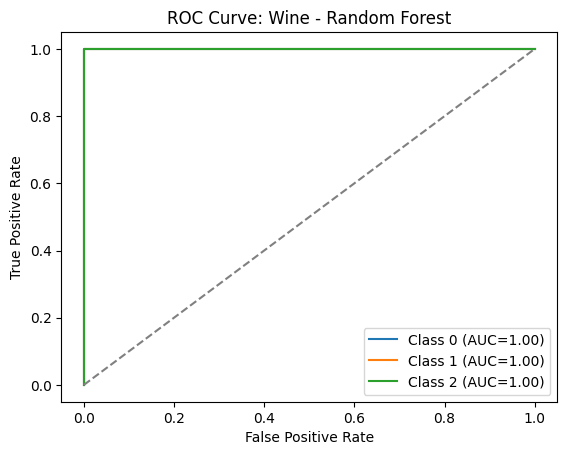

In [ ]:
rf_model = RandomForestClassifier(n_estimators=95, random_state=42)
evaluate_random_forest(rf_model, Xw_train, Xw_test, yw_train, yw_test, dataset_name="Wine")

#TEST SIZE WINE
This code compares how SVM (RBF), MLP, and Random Forest perform on the Wine dataset with different train-test splits (10%–90% test size). For each split, the models are trained, tested, and their accuracies recorded. A line plot is then drawn to show accuracy vs. test size, allowing us to see how each model’s performance changes as the training data decreases.

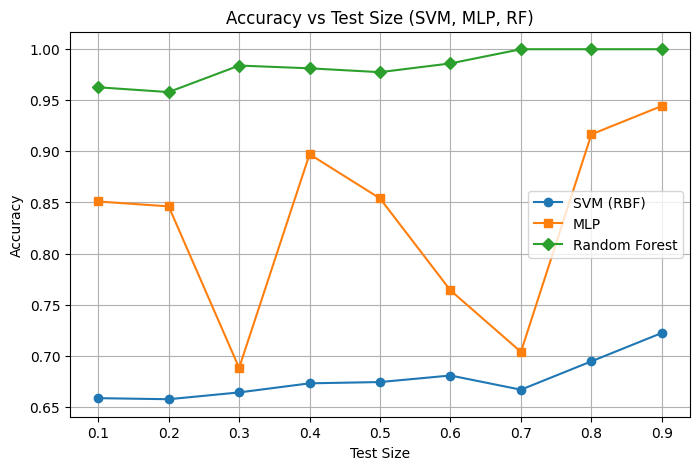

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

splits = range(1, 10)   # test sizes from 0.1 to 0.9
accs_svm = []
accs_mlp = []
accs_rf = []



for s in splits:
    test_size = s / 10


    X_train, X_test, y_train, y_test = train_test_split(X_wine, y_wine, train_size=test_size, stratify=y_wine, random_state=42)


    # --- SVM ---
    svm_model = SVC(kernel="rbf", probability=True, random_state=42)
    svm_model.fit(X_train, y_train)
    accs_svm.append(accuracy_score(y_test, svm_model.predict(X_test)))

    # --- MLP ---
    mlp_model = MLPClassifier(
        hidden_layer_sizes=(100,),
        learning_rate_init=0.01,
        momentum=0.9,
        max_iter=200,
        random_state=42
    )
    mlp_model.fit(X_train, y_train)
    accs_mlp.append(accuracy_score(y_test, mlp_model.predict(X_test)))

    # --- Random Forest ---
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    accs_rf.append(accuracy_score(y_test, rf_model.predict(X_test)))

# Convert to fractions
splits = [s/10 for s in splits]

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(splits, accs_svm, marker="o", label="SVM (RBF)")
plt.plot(splits, accs_mlp, marker="s", label="MLP")
plt.plot(splits, accs_rf, marker="D", label="Random Forest")
plt.xlabel("Test Size")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Test Size (SVM, MLP, RF)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
Xw_train[0].size

13

#PCA WINE
The Wine dataset was reduced to eight principal components using PCA, with the first two components visualized in a scatter plot to show class separation. On this reduced data, an SVM with a linear kernel and an MLP with one hidden layer of 100 neurons were trained to evaluate classification performance after dimensionality reduction.

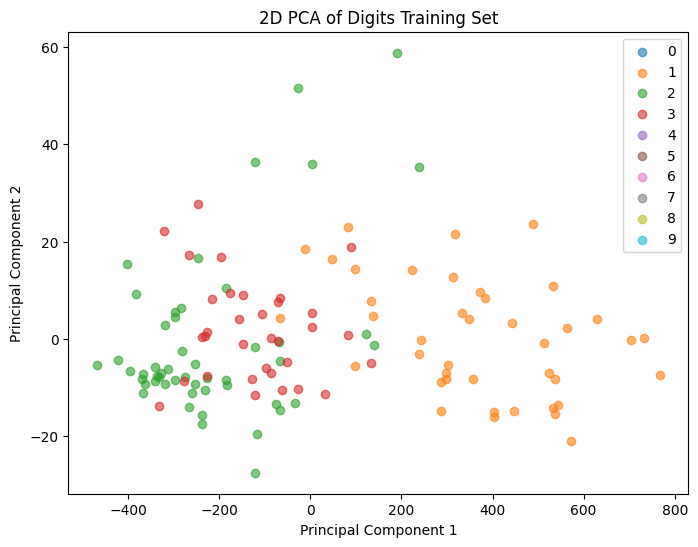

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA to reduce to 2 dimensions for visualization
pca_2d = PCA(n_components=8)
X_wine_2d = pca_2d.fit_transform(X_wine)
Xw_train_2d, Xw_test_2d, yw_train_2d, yw_test_2d = train_test_split(
    X_wine_2d, y_wine, train_size=0.7, stratify=y_wine, random_state=42
)
# Plot the 2D PCA projection
plt.figure(figsize=(8,6))
for digit in range(10):
    plt.scatter(
        Xw_train_2d[yw_train_2d == digit, 0],
        Xw_train_2d[yw_train_2d == digit, 1],
        label=str(digit), alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA of Digits Training Set")
plt.legend()
plt.show()


In [ ]:
Xw_train_2d[0].size
#

8


[WIne] SVM-Sigmoid
Accuracy: 0.9630, Precision: 0.9662, Recall: 0.9630, F1: 0.9625

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        18
           2       0.91      1.00      0.95        21
           3       1.00      0.87      0.93        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



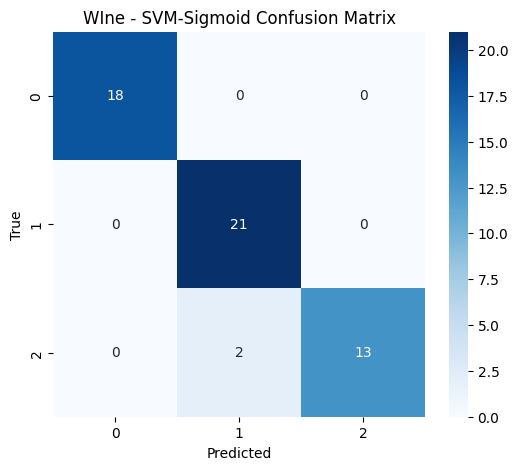

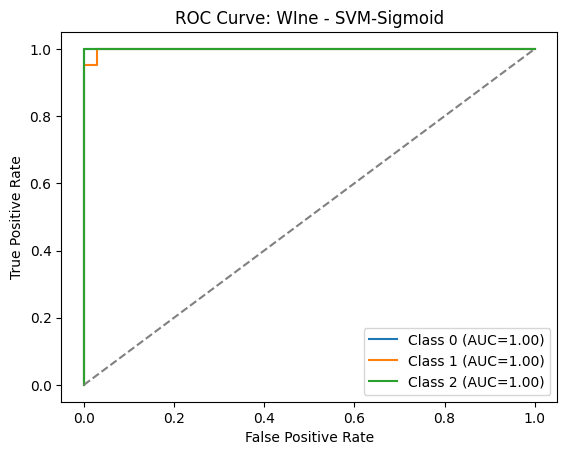

In [ ]:
# Digits - SVM Sigmoid
svm_sigmoid_wine = SVC(kernel="linear", probability=True, random_state=42)
evaluate_svm(svm_sigmoid_wine, Xw_train_2d, Xw_test_2d, yw_train_2d, yw_test_2d, "WIne", "Sigmoid")



[Wine] MLP
Accuracy: 0.9630, Precision: 0.9662, Recall: 0.9630, F1: 0.9625

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        18
           2       0.91      1.00      0.95        21
           3       1.00      0.87      0.93        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



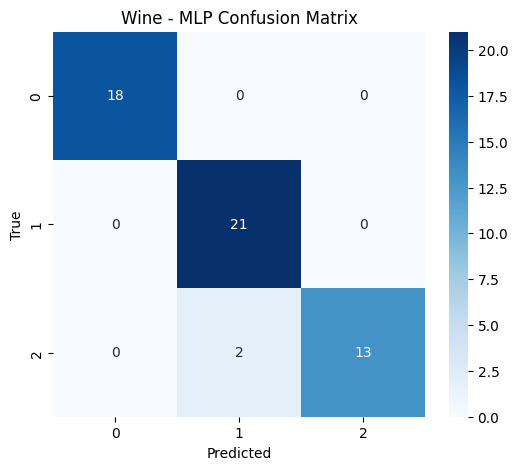

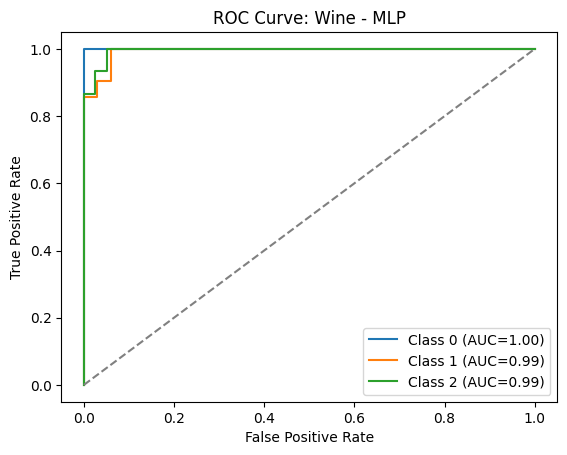

In [ ]:
evaluate_mlp(hidden_layer_sizes=(100,),   # one hidden layer with 100 neurons
             learning_rate_init=0.01,     # learning rate
             momentum=0.9,                # momentum term
             max_iter=200,                # epoch size
             X_train=Xw_train_2d, X_test=Xw_test_2d,
             y_train=yw_train_2d, y_test=yw_test_2d,
             dataset_name="Wine")



[Wine] Random Forest
Accuracy: 0.9630, Precision: 0.9662, Recall: 0.9630, F1: 0.9625

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        18
           2       0.91      1.00      0.95        21
           3       1.00      0.87      0.93        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



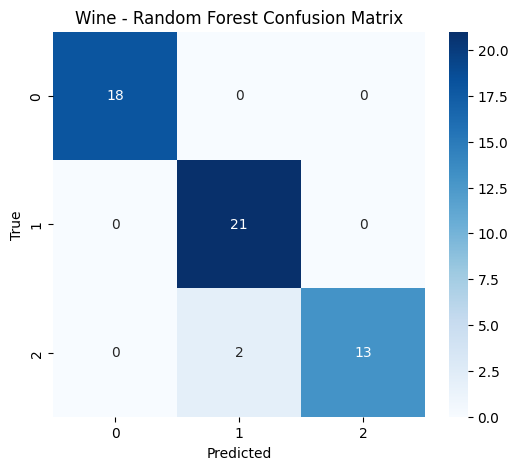

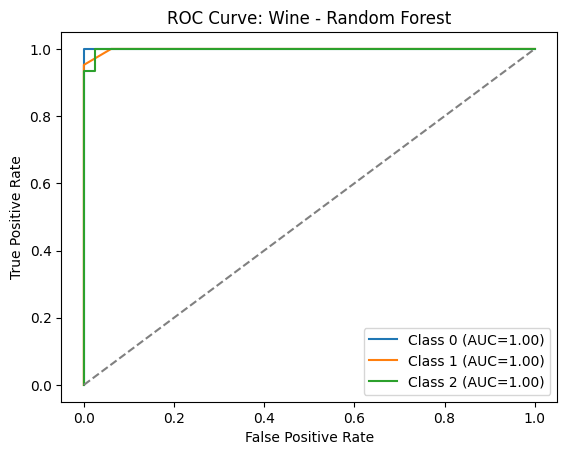

In [ ]:
rf_model = RandomForestClassifier(n_estimators=95, random_state=42)
evaluate_random_forest(rf_model, Xw_train_2d, Xw_test_2d, yw_train_2d, yw_test_2d, dataset_name="Wine")